In [1]:
# Import necessary libraries

import nltk  # pip install nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud  # pip install wordcloud
from textblob import TextBlob  # pip install textblob


In [2]:
# Download necessary datasets
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

text = """Text mining is a component of data mining that deals specifically with unstructured text data.
It involves the use of natural language processing (NLP) techniques to extract useful information
and insights from large amounts of unstructured text data.
Text mining can be used as a preprocessing step for data mining or as a standalone process for specific tasks."""

# Step 1: Tokenization (splitting text into words)
tokens = word_tokenize(text.lower())  # Convert to lowercase

# Step 2: Remove stopwords and punctuation
stop_words = set(stopwords.words("english"))
filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]

# Step 3: Word frequency analysis
word_freq = Counter(filtered_tokens)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# Step 4: Sentiment Analysis

# Polarity (ranges from -1 to +1):
#   -1 = Very negative
#    0 = Neutral
#   +1 = Very positive

# Subjectivity (ranges from 0 to 1):
#    0 = Objective/factual
#    1 = Highly subjective/opinionated

sentiment = TextBlob(text).sentiment
print(f"Sentiment Analysis:\nPolarity: {sentiment.polarity},  Subjectivity: {sentiment.subjectivity}")


Sentiment Analysis:
Polarity: 0.15357142857142858,  Subjectivity: 0.23839285714285713


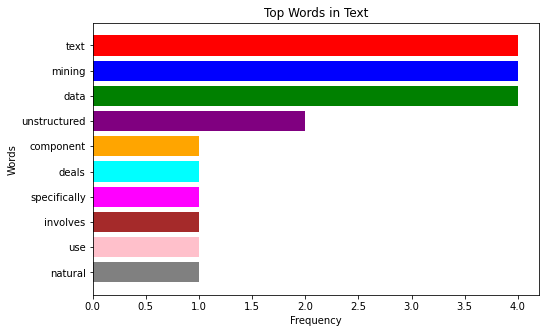

In [4]:
# Step 5: Plot Word Frequency
color_list = ["red", "blue", "green", "purple", "orange", "cyan", "magenta", "brown", "pink", "gray"]

plt.figure(figsize=(8, 5))
plt.barh(
    [word for word, freq in word_freq.most_common(10)],
    [freq for word, freq in word_freq.most_common(10)],
    color=color_list[:len(word_freq)]
)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top Words in Text")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


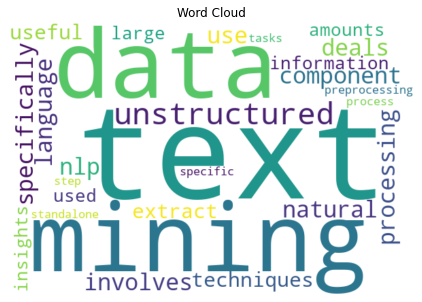

In [5]:
# Step 6: Generate Word Cloud
wordcloud = WordCloud(width=600, height=400, background_color="white").generate(" ".join(filtered_tokens))

# Step 7: Plot Word Cloud
plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()
